# Handwritten Digit Recognition using CNN
## AI Internship Project
 Name : Shravani Mukane
 #
 Course : BSc Data Science (3rd Year)


# CNN Model on MNIST Dataset for Handwritten Digit Classification

## Introduction

Handwritten digit classification is a fundamental computer vision task.
In this project, a Convolutional Neural Network (CNN) is implemented
to classify digits (0–9) from the MNIST dataset.

CNN is chosen because it preserves spatial structure of images
and performs better than traditional fully connected networks.

In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Step 1 — Import All Required Libraries

In [2]:
# Numerical operations
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

Step 2 — Load MNIST Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


STEP 3 — Dataset Visualization

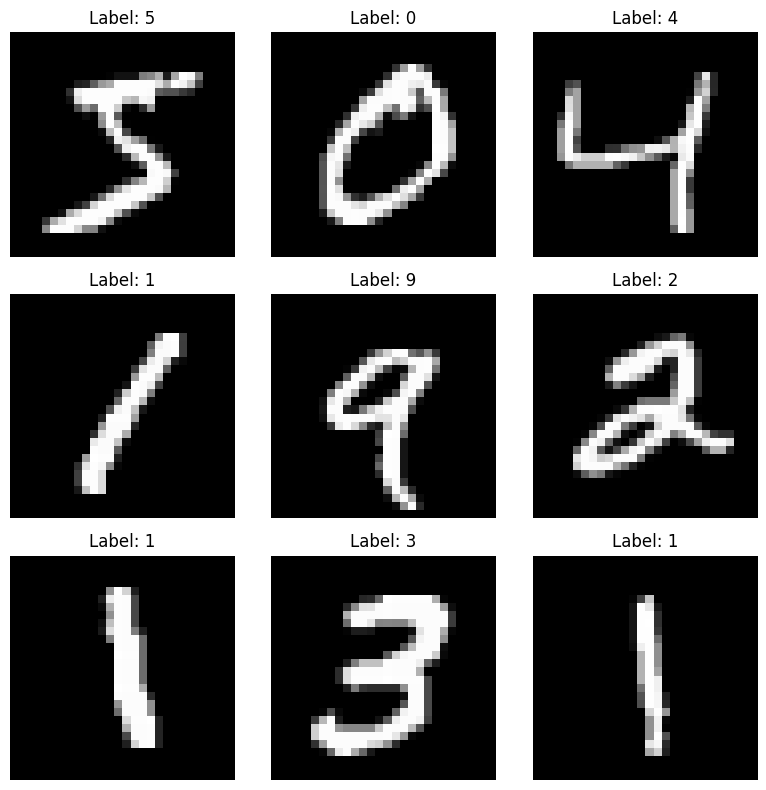

In [4]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observations

- Each image is 28 × 28 pixels in grayscale format.
- The digits vary in thickness, orientation, and writing style.
- Some digits appear similar (e.g., 3 and 5, 4 and 9), which can make classification challenging.

STEP 4 — Data Preprocessing (Normalization)

In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Min value:", x_train.min())
print("Max value:", x_train.max())

Min value: 0.0
Max value: 1.0


STEP 5 — Reshape for CNN

In [6]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("New training shape:", x_train.shape)
print("New test shape:", x_test.shape)

New training shape: (60000, 28, 28, 1)
New test shape: (10000, 28, 28, 1)


## CNN Architecture

In [7]:
cnn_model = models.Sequential()

# First Convolution Block
cnn_model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
cnn_model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Block
cnn_model.add(layers.Conv2D(64, (3,3), activation='relu'))
cnn_model.add(layers.MaxPooling2D((2,2)))

# Flatten and Dense Layers
cnn_model.add(layers.Flatten())
cnn_model.add(layers.Dense(128, activation='relu'))
cnn_model.add(layers.Dropout(0.5))

# Output Layer
cnn_model.add(layers.Dense(10, activation='softmax'))

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

STEP 6 — Compile the Model

In [8]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

STEP 7 — Train the CNN

In [9]:
history = cnn_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8359 - loss: 0.5208 - val_accuracy: 0.9855 - val_loss: 0.0524
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9698 - loss: 0.0980 - val_accuracy: 0.9897 - val_loss: 0.0392
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9793 - loss: 0.0681 - val_accuracy: 0.9880 - val_loss: 0.0422
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9830 - loss: 0.0559 - val_accuracy: 0.9872 - val_loss: 0.0453
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9855 - loss: 0.0454 - val_accuracy: 0.9903 - val_loss: 0.0322


### Observations

- Accuracy improved significantly after the first epoch.
- Both training and validation accuracy reached around 98–99%.
- Training and validation results are very close, indicating no major overfitting.
- The model is learning effectively and generalizing well.

STEP 8 — Evaluate on Test Data

In [10]:
test_loss, test_accuracy = cnn_model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9874 - loss: 0.0349
Test Accuracy: 0.9904000163078308


### Test Results

- The model achieved approximately 99% accuracy on the test dataset.
- Test accuracy is consistent with validation accuracy.
- This indicates that the model generalizes well to unseen data.

STEP 9 — Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


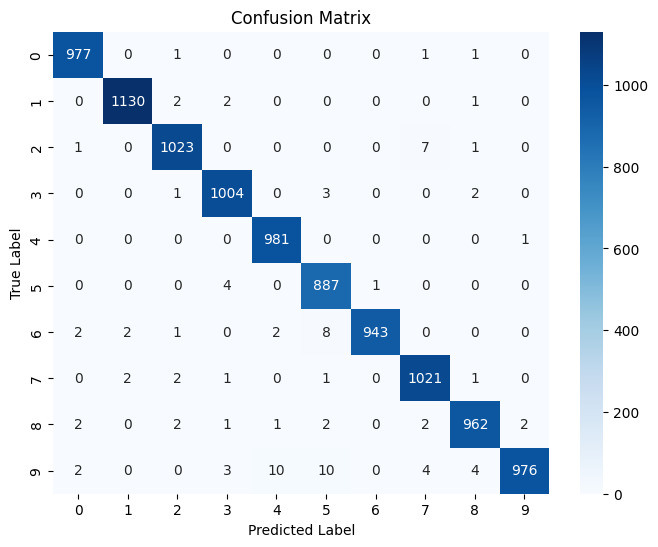

In [11]:
y_pred = cnn_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Analysis

- Most predictions lie along the diagonal, indicating correct classification.
- Very few misclassifications are observed.
- Some confusion can be seen between visually similar digits such as:
  - 5 and 3
  - 4 and 9
- Overall, the model performs consistently across all digit classes.

STEP 10 — Plot Training vs Validation Accuracy

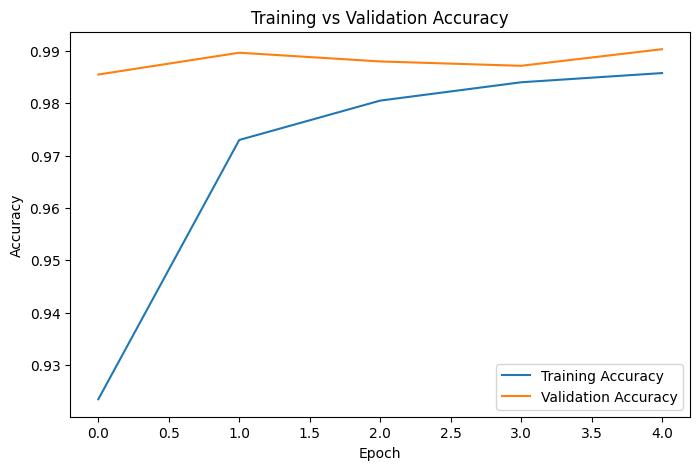

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Accuracy Curve Analysis

- Training accuracy increases steadily across epochs.
- Validation accuracy remains consistently high.
- Both curves are close to each other, indicating no overfitting.
- The model demonstrates stable and effective learning.

STEP 11 — Show Misclassified Images

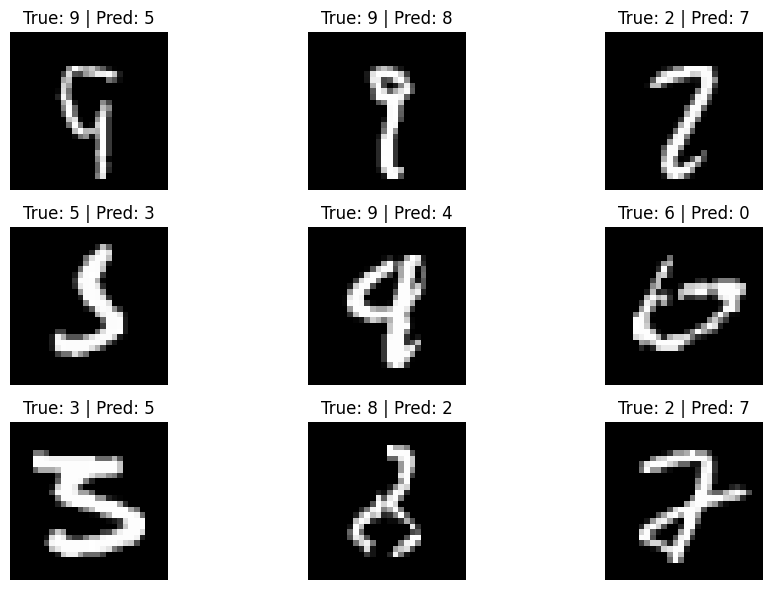

In [13]:
# Get incorrect predictions
misclassified_indexes = np.where(y_pred_classes != y_test)[0]

plt.figure(figsize=(10,6))

for i in range(9):
    index = misclassified_indexes[i]

    plt.subplot(3,3,i+1)
    plt.imshow(x_test[index].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test[index]} | Pred: {y_pred_classes[index]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observations

- Few digits are misclassified.
- Errors mainly occur between visually similar digits.
- The model performs well overall with very low error rate.

STEP 12 — Build Improved CNN Mode

In [14]:
cnn_bn_model = models.Sequential()

cnn_bn_model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
cnn_bn_model.add(layers.BatchNormalization())
cnn_bn_model.add(layers.MaxPooling2D((2,2)))

cnn_bn_model.add(layers.Conv2D(64, (3,3), activation='relu'))
cnn_bn_model.add(layers.BatchNormalization())
cnn_bn_model.add(layers.MaxPooling2D((2,2)))

cnn_bn_model.add(layers.Flatten())
cnn_bn_model.add(layers.Dense(128, activation='relu'))
cnn_bn_model.add(layers.Dropout(0.5))

cnn_bn_model.add(layers.Dense(10, activation='softmax'))

cnn_bn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_bn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

STEP 13 — Train BatchNorm Model

In [15]:
history_bn = cnn_bn_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8613 - loss: 0.4770 - val_accuracy: 0.9845 - val_loss: 0.0535
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9730 - loss: 0.0947 - val_accuracy: 0.9878 - val_loss: 0.0433
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9797 - loss: 0.0672 - val_accuracy: 0.9882 - val_loss: 0.0477
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9829 - loss: 0.0550 - val_accuracy: 0.9863 - val_loss: 0.0544
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9845 - loss: 0.0516 - val_accuracy: 0.9893 - val_loss: 0.0440


In [16]:
test_loss_bn, test_accuracy_bn = cnn_bn_model.evaluate(x_test, y_test)
print("Test Accuracy with BatchNorm:", test_accuracy_bn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9860 - loss: 0.0506
Test Accuracy with BatchNorm: 0.9891999959945679


### Comparison with Original CNN Model

- The CNN model with Batch Normalization achieved similar accuracy compared to the original CNN.
- There is no significant improvement in validation performance.
- Since MNIST is a relatively simple dataset, the original CNN architecture was already sufficient.
- Batch Normalization did not provide a noticeable advantage in this case.